## Business Problem

Telecommunication companies face significant revenue loss due to customer churn. Retaining existing customers is more cost-effective than acquiring new ones, making churn prediction a critical business priority.

## Objective

The goal of this project is to develop a machine learning model that predicts customers likely to churn and identifies the key factors driving churn behavior.

## Success Metric

The model prioritizes recall to ensure that the majority of at-risk customers are identified for proactive retention strategies.

In [1]:
# ----- Data Handling ------
import pandas as pd
import numpy as np

# ----- Visualization ------
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)


In [2]:
# import datase
df = pd.read_csv(r'/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **Initial Observation:**
###- Dataset contains customer-level telecom data
### - Columns include demographic, service usage, and billing information
### - Target variable 'Churn' indicates whether a customer left

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Dataset Summary (from `df.info()`):

- **Total Entries:** 7043
- **Total Columns:** 21
- **Data Types:**
  - `object`: 18 columns
  - `int64`: 2 columns
  - `float64`: 1 column
- `TotalCharges` is of type `object` and should likely be numeric, which might indicate hidden missing values or parsing issues. This will need further investigation and cleaning

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Missing Values:** No explicitly missing values shown by `Non-Null Count` for any column

In [5]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## **Observations:**
 - Dataset is imbalanced (more non-churn than churn)
- This may affect model performance and evaluation

# **Data Cleaning**

In [6]:
# Convert to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Create a copy of original dataset before cleaning
df_copy = df.copy()

In [7]:
# Remove leading/trailing spaces from categorical columns
for col in df_copy.select_dtypes(include='object').columns:
    df_copy[col] = df_copy[col].str.strip()

In [8]:
# Check duplicates
df_copy.duplicated().sum()

np.int64(0)

In [9]:
# check for inconsistent values
for col in df_copy.select_dtypes(include='object').columns:
    print(col, df_copy[col].unique())
    print('\n')

customerid ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']


gender ['Female' 'Male']


partner ['Yes' 'No']


dependents ['No' 'Yes']


phoneservice ['No' 'Yes']


multiplelines ['No phone service' 'No' 'Yes']


internetservice ['DSL' 'Fiber optic' 'No']


onlinesecurity ['No' 'Yes' 'No internet service']


onlinebackup ['Yes' 'No' 'No internet service']


deviceprotection ['No' 'Yes' 'No internet service']


techsupport ['No' 'Yes' 'No internet service']


streamingtv ['No' 'Yes' 'No internet service']


streamingmovies ['No' 'Yes' 'No internet service']


contract ['Month-to-month' 'One year' 'Two year']


paperlessbilling ['Yes' 'No']


paymentmethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


totalcharges ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']


churn ['No' 'Yes']




In [10]:
df_copy[df_copy['monthlycharges'] == 0]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn


In [11]:
# Fix logical inconsistency:
# Customers with tenure = 0 should have totalcharges = 0
df_copy.loc[df_copy['tenure'] == 0, 'totalcharges'] = 0

In [12]:
df_copy[(df_copy['internetservice'] == 'No') & (df_copy['onlinesecurity'] == 'Yes')]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn


In [13]:
df_copy['totalcharges'] = pd.to_numeric(df_copy['totalcharges'], errors='coerce')

In [14]:
df_copy.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# **Data Cleaning Summary:**
 - Standardized column names
 - Created a working copy of dataset
 - Converted totalcharges to numeric and handled missing values
 - Checked and removed duplicates (if any)
 - Ensured consistency in categorical values
 - Validated numerical columns and logical consistency
 - Prepared dataset for exploratory analysis

# **EDA**

## Business Objective

The objective of this project is to analyze customer churn behavior in a telecommunications company and develop a machine learning solution capable of predicting customers likely to churn.

This analysis focuses on identifying:
- Customer segments with high churn risk
- Service-related drivers of churn
- Revenue-related churn patterns
- Behavioral indicators associated with customer retention

The findings from this analysis will support proactive customer retention strategies.

In [15]:
df_copy.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
# create working DataFrame for EDA
eda_df = df_copy.copy()

### **Target Variable Analysis**

In [17]:
# Check the number of customers in each churn category
eda_df['churn'].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [18]:
# Check churn percentage distribution

eda_df['churn'].value_counts(normalize=True) * 100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

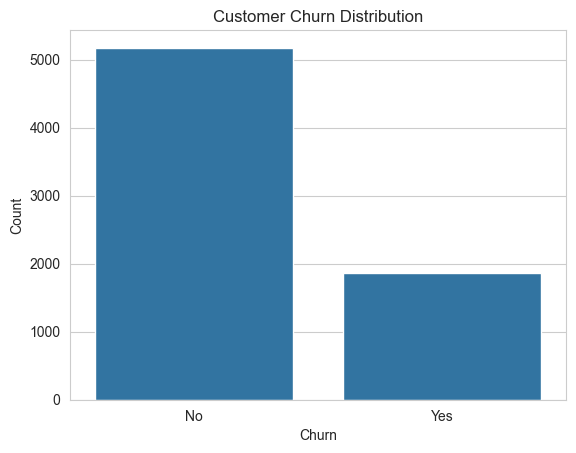

In [19]:
# Visualize churn distribution

sns.countplot(data=eda_df, x='churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

### Target Variable Insight

The dataset contains a higher proportion of retained customers (73.46%) compared to churned customers (26.54%).

This indicates a moderate class imbalance in the target variable, where non-churned customers significantly outnumber churned customers.

From a business perspective, identifying customers likely to churn is critically important because customer retention is generally more cost-effective than acquiring new customers.

### **Numeric Feature Analysis**

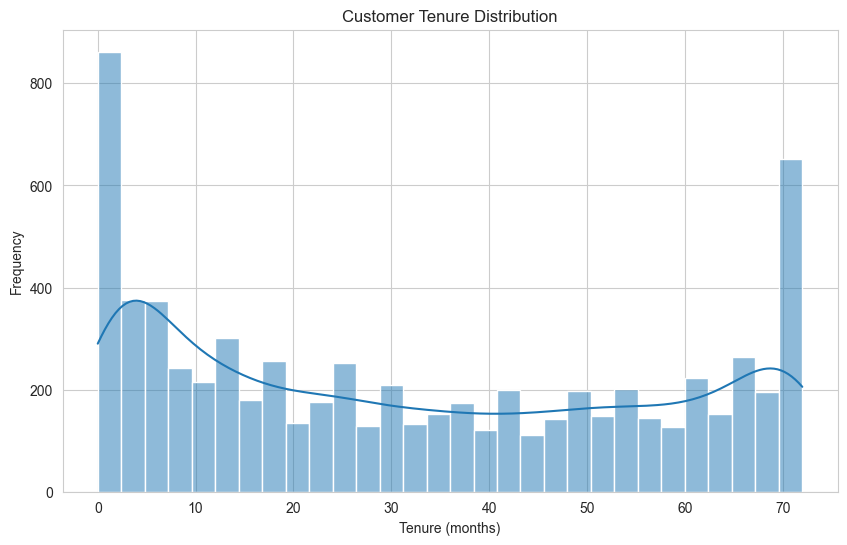

In [20]:
# Analyze customer tenure distribution

plt.figure(figsize=(10, 6))
sns.histplot(data=eda_df, x='tenure' , bins=30, kde=True)
plt.title('Customer Tenure Distribution')
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')
plt.show()

### Tenure Distribution Insight

The tenure distribution exhibits a non-normal pattern with noticeable concentration at both low and high tenure levels.

A significant proportion of customers have very short tenure, suggesting that many customers either recently joined the service or tend to churn during the early stages of subscription.

Another concentration appears among long-tenure customers, indicating the presence of loyal customers who maintain long-term relationships with the company.

The relatively lower concentration of mid-tenure customers may suggest a transition pattern where customers either churn early or remain long enough to become stable subscribers.

### Additional Analytical Observation

The relatively lower concentration of customers in the mid-tenure range may indicate that some customers churn before reaching long-term loyalty status.

This pattern could potentially reflect customer dissatisfaction factors such as pricing concerns, service quality issues, or unmet expectations during the customer lifecycle.

Another possible explanation is the presence of onboarding incentives for new customers and retention benefits for long-term subscribers, which may contribute to higher customer concentration at both early and late tenure stages.

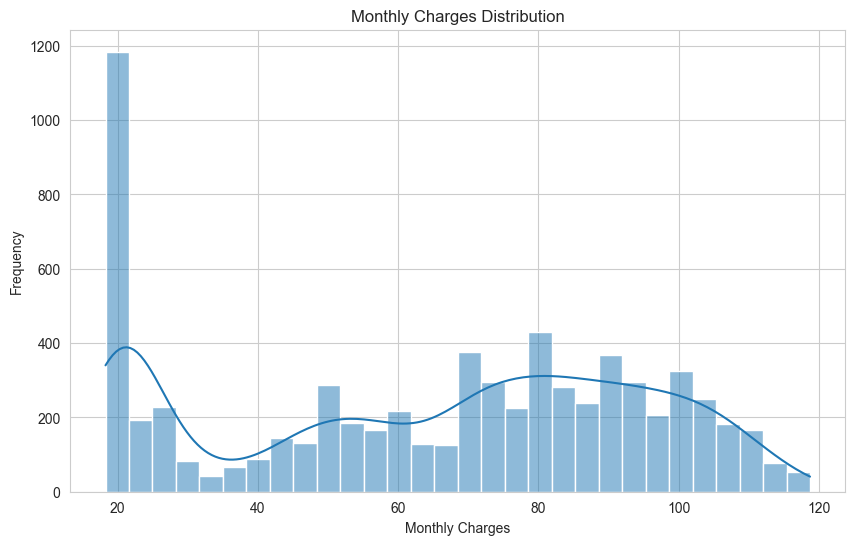

In [21]:
# Analyze monthly charges distribution

plt.figure(figsize=(10, 6))
sns.histplot(data=eda_df, x='monthlycharges', bins=30, kde=True)
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.show()

### Monthly Charges Distribution Insight

The monthly charges distribution exhibits multiple concentration peaks, suggesting the presence of several customer pricing tiers and service package categories.

Lower charge ranges likely represent customers subscribed to basic telecom services, while higher charge ranges may correspond to customers using premium or bundled services such as fiber internet, streaming platforms, online security, and technical support.

The clustering pattern indicates that customers tend to subscribe to specific service combinations rather than uniformly distributed pricing plans.

This distribution also suggests the existence of distinct customer segments based on service consumption and pricing preferences.

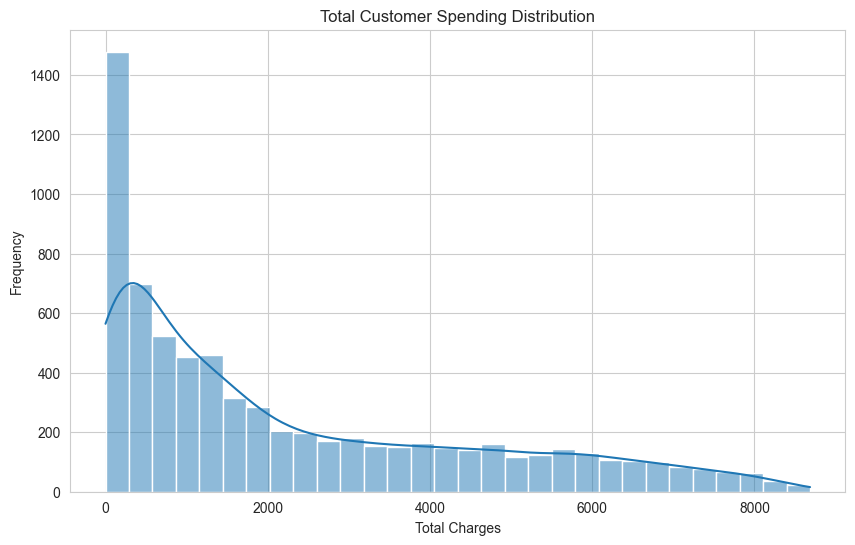

In [22]:
# Analyze total customer spending distribution

plt.figure(figsize=(10, 6))
sns.histplot(data=eda_df, x='totalcharges', bins=30, kde=True)
plt.title('Total Customer Spending Distribution')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.show()


### Total Charges Distribution Insight

The total charges distribution exhibits strong positive skewness, with a large concentration of customers within the lower spending range.

This pattern suggests that many customers either have relatively short tenure or have not accumulated substantial long-term spending with the company.

A smaller group of customers contributes very high total charges, likely representing long-tenure and high-value customers with greater customer lifetime value.

The extended right tail indicates the presence of a valuable loyal customer segment that may contribute significantly to overall company revenue.

In [23]:
# Summary statistics for numerical features

eda_df[['tenure', 'monthlycharges', 'totalcharges']].describe()

,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


### Statistical Summary Insight

The numerical features exhibit varying distribution patterns and levels of variability across customers.

The `tenure` feature shows substantial variation in customer retention behavior, with customers ranging from newly subscribed users to long-term loyal subscribers. The mean tenure is slightly higher than the median, suggesting mild positive skewness driven by long-tenure customers.

`monthlycharges` demonstrates moderate variability, indicating the presence of multiple pricing tiers and service package categories across customers. The relatively small difference between the mean and median suggests a more balanced distribution compared to other numerical features.

`totalcharges` exhibits strong positive skewness, with a large concentration of customers in the lower spending range and a smaller group of high-value customers contributing substantially higher cumulative revenue. The large standard deviation further indicates significant variation in customer lifetime value.

Overall, the statistical summary suggests the presence of multiple customer segments with distinct retention behavior, pricing structures, and spending patterns.

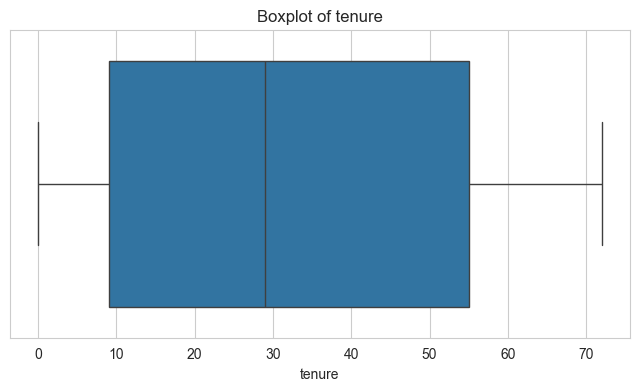

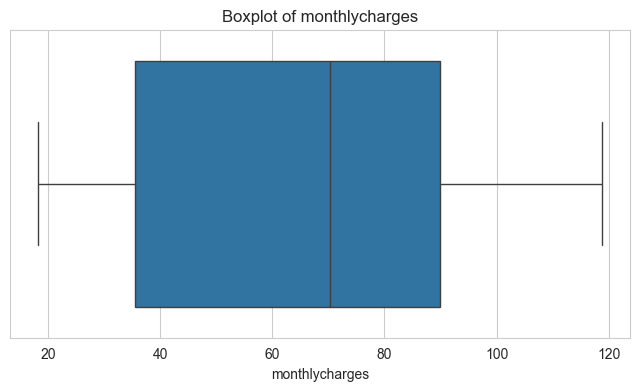

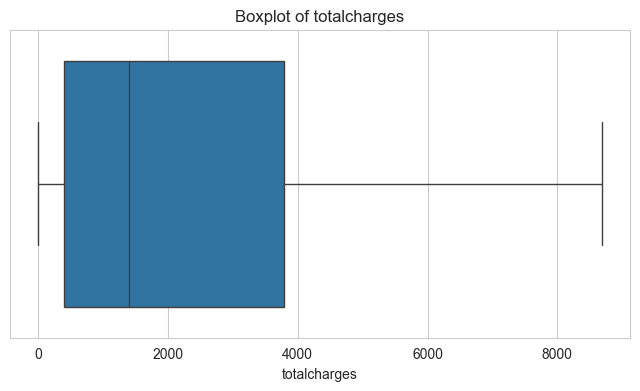

In [24]:
# Visualize numerical feature spread and potential outliers

numerical_features = ['tenure', 'monthlycharges', 'totalcharges']
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=eda_df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.show()

### Boxplot Analysis Insight

The boxplots indicate substantial variability across the numerical features, particularly in `tenure` and `totalcharges`, reflecting diverse customer retention and spending behaviors.

No significant extreme outliers were observed beyond the whisker boundaries, suggesting that the observed high-value ranges are likely legitimate customer behaviors rather than data quality issues.

The elongated spread in `totalcharges` further reinforces the presence of customers with substantially different lifetime value profiles, while `monthlycharges` exhibits comparatively more stable pricing variation across customers.

### **Bivariate Analysis**

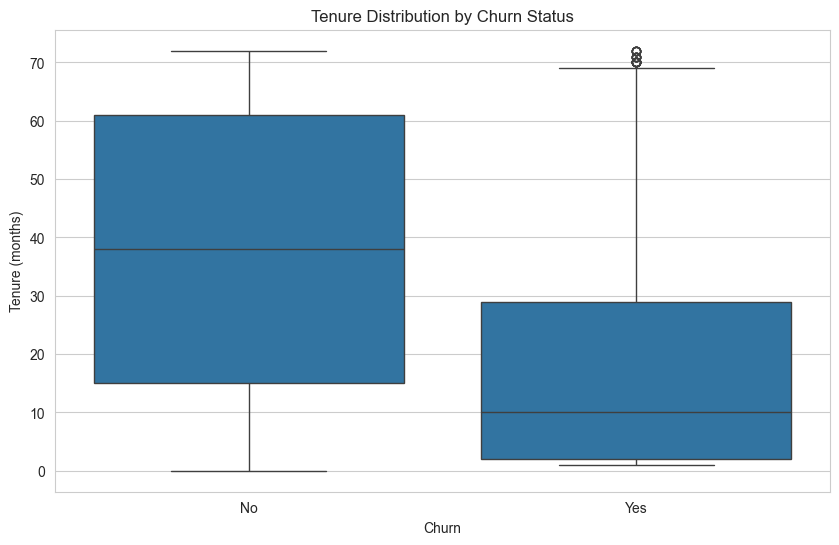

In [25]:
# Compare tenure distribution across churn groups

plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='tenure', data=eda_df)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.show()


### Tenure vs Churn Insight

Customers who churn generally have much lower tenure than customers who remain with the company. Most churned customers are concentrated within the early months of their subscription.

This suggests that the risk of churn is highest during the early stages of the customer journey. Customers who stay longer with the company are more likely to remain loyal over time.

Long-term customers may be less likely to leave because they are already familiar with the service, receive loyalty benefits, or face higher switching costs when moving to another provider.

The result shows that early customer retention is very important. Improving onboarding experience, customer support, and early customer engagement could help reduce churn before customers fully leave the service.

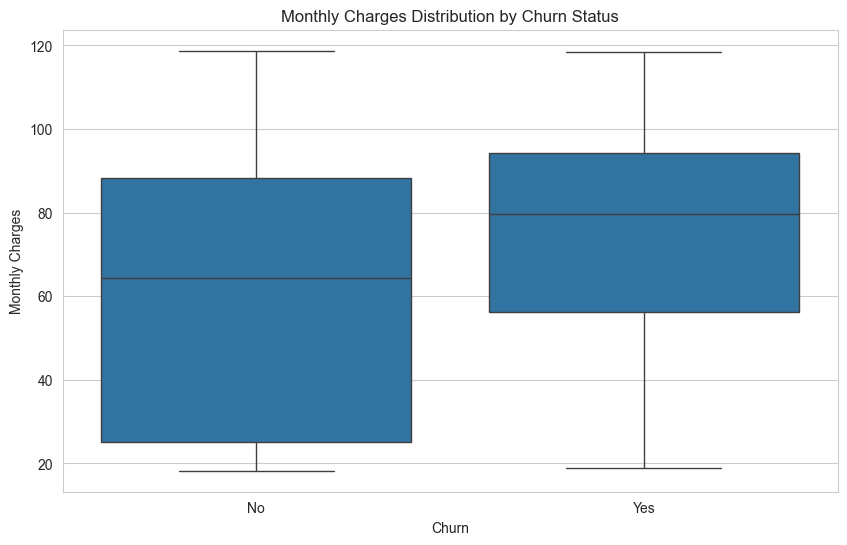

In [26]:
# Compare monthly charges across churn groups

plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='monthlycharges', data=eda_df)
plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

### Monthly Charges vs Churn Insight

Customers who churn tend to pay higher monthly charges than customers who stay with the company. This suggests that pricing may play an important role in churn behavior.

Customers paying for more expensive or bundled services may expect better service quality and support. When those expectations are not met, they may be more willing to switch to competitors offering better value or lower prices.

This pattern may be more common among newer customers who have not fully committed to the company’s services and can still switch providers easily.

The result shows that high-paying customers are an important risk group for churn. Improving service quality, customer experience, and the value customers receive for the price they pay could help reduce churn among these customers.

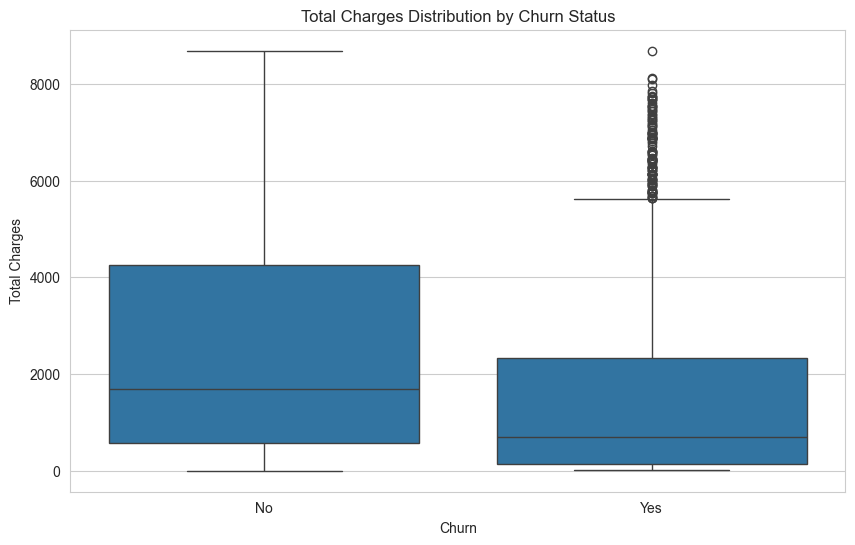

In [27]:
# Compare total charges across churn groups
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='totalcharges', data=eda_df)
plt.title('Total Charges Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Total Charges')
plt.show()

### Total Charges vs Churn Insight

Customers who stayed with the company generally have higher total charges than customers who churned. This is expected because long-term customers continue paying for services over time, leading to higher cumulative spending.

Most churned customers have lower total charges, which supports earlier findings that many customers leave within the early stages of their subscription.

However, there are still some churned customers with very high total charges. This shows that even valuable or long-term customers can leave the company, possibly due to pricing concerns, poor service experience, or better alternatives from competitors.

The result suggests that customer value alone does not guarantee retention. The company should focus not only on keeping new customers but also on maintaining satisfaction among high-value customers to reduce revenue loss from churn.

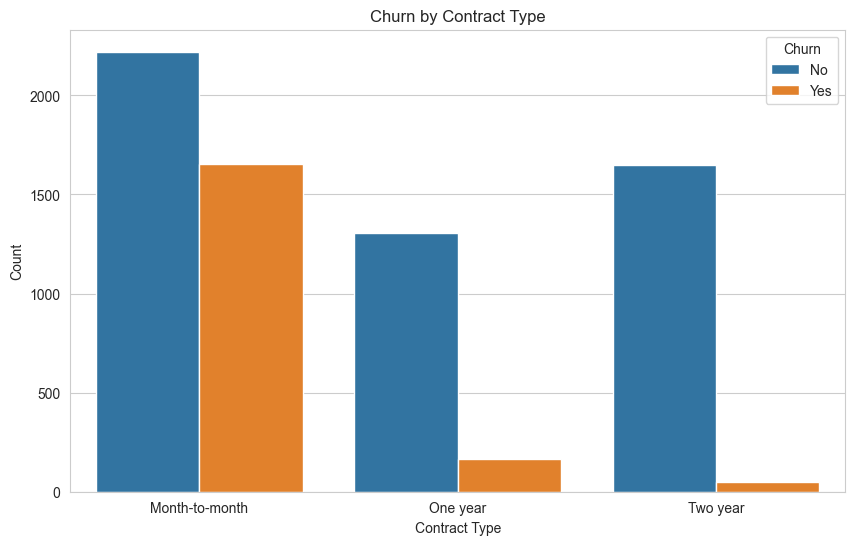

In [28]:
# Analyze relationship between contract type and churn
plt.figure(figsize=(10, 6))
sns.countplot(x='contract', hue='churn', data=eda_df)
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn', loc='upper right')
plt.show()


### Contract Type vs Churn Insight

Customers on month-to-month contracts show the highest churn compared to customers on one-year and two-year contracts.

This suggests that customers with shorter contracts are more likely to switch services because they are not tied to long-term commitments. They may also be more sensitive to pricing, service quality, or better offers from competitors.

On the other hand, customers with longer contracts tend to stay longer with the company. This may be because they are already used to the service, receive contract benefits, or face higher switching costs when trying to move to another provider.

The result shows that contract type plays an important role in customer retention. Encouraging customers to move from month-to-month plans to longer-term contracts could help reduce churn.

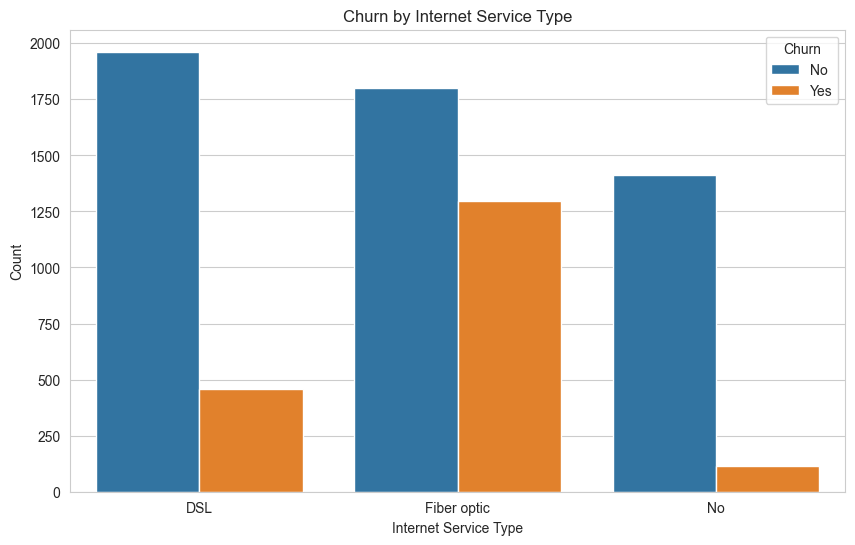

In [29]:
# Analyze internet service categories against churn
plt.figure(figsize=(10, 6))
sns.countplot(x='internetservice', hue='churn', data=eda_df)
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Count')
plt.legend(title='Churn', loc='upper right')
plt.show()

### Internet Service vs Churn Insight

Customers using fiber optic internet show the highest churn compared to DSL and customers without internet service.

This may be because fiber optic customers usually pay more for premium internet services and therefore expect better speed, reliability, and customer support. When those expectations are not met, they may be more willing to switch to competitors.

DSL and non-internet customers show lower churn levels, possibly because they use simpler or lower-cost services with fewer expectations and lower pricing pressure.

The result suggests that the company should pay close attention to the experience of fiber optic customers by improving service quality, customer support, and pricing competitiveness to reduce churn in this group.

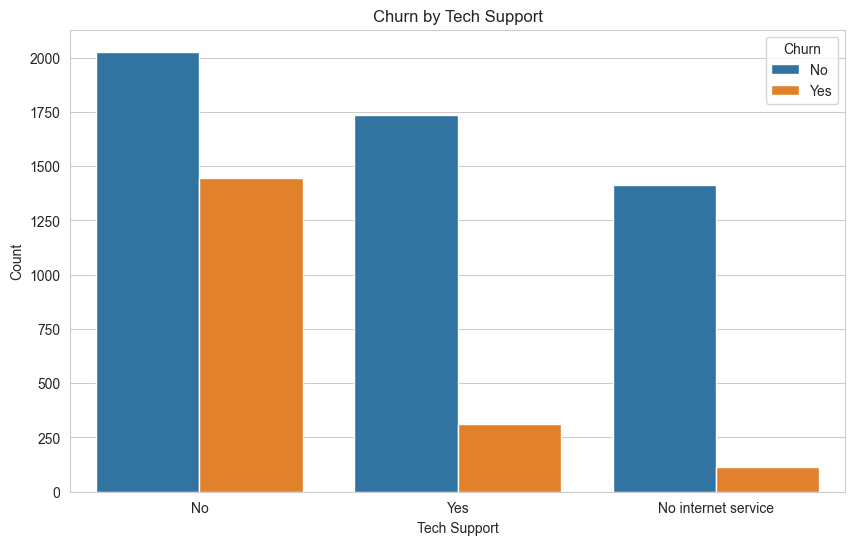

In [30]:
# Analyze technical support against churn
plt.figure(figsize=(10, 6))
sns.countplot(x='techsupport', hue='churn', data=eda_df)
plt.title('Churn by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.legend(title='Churn', loc='upper right')
plt.show()

### Tech Support vs Churn Insight

Customers without tech support show much higher churn compared to customers who have access to technical support services.

This suggests that customer support plays an important role in retention. Customers are more likely to remain with the company when they can quickly resolve service issues and receive reliable assistance when problems occur.

The result may be especially important for customers using internet or premium services, where service interruptions or technical problems can strongly affect customer experience and satisfaction.

Customers without internet service show relatively low churn, likely because they depend less on internet-related support services.

Overall, the findings suggest that improving technical support quality and accessibility could help reduce customer churn and improve customer satisfaction.

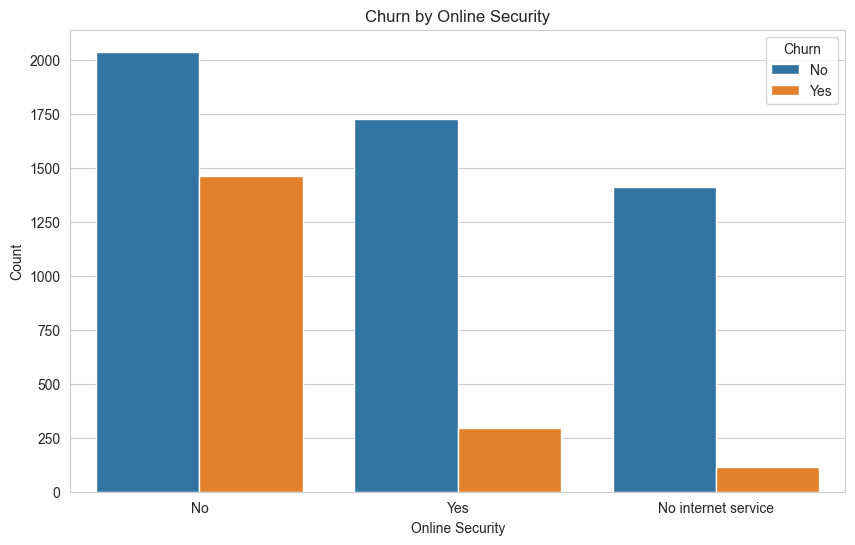

In [31]:
# Analyze online security against churn
plt.figure(figsize=(10, 6))
sns.countplot(x='onlinesecurity', hue='churn', data=eda_df)
plt.title('Churn by Online Security')
plt.xlabel('Online Security')
plt.ylabel('Count')
plt.legend(title='Churn', loc='upper right')
plt.show()

### Online Security vs Churn Insight

Customers without online security services show much higher churn compared to customers who use online security features.

This suggests that additional security services may help improve customer trust, satisfaction, and overall retention. Customers who feel their data and online activities are protected may be more comfortable staying with the company.

The result also indicates that customers using extra services such as online security are likely more connected to the company’s service ecosystem, making them less likely to switch providers.

Overall, the findings suggest that bundled value-added services like online security can play an important role in reducing churn and improving customer loyalty.

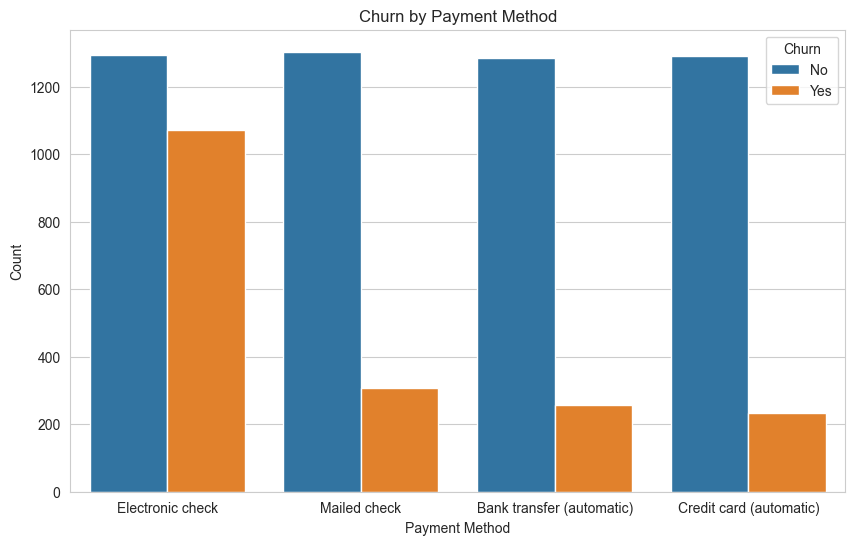

In [32]:
# Analyze payment method against churn
plt.figure(figsize=(10, 6))
sns.countplot(x='paymentmethod', hue='churn', data=eda_df)
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.legend(title='Churn', loc='upper right')
plt.show()

### Payment Method vs Churn Insight

Customers using electronic check payment show much higher churn compared to customers using other payment methods.

On the other hand, customers using automatic payment methods such as bank transfer and credit card show lower churn levels. This suggests that automatic payment systems may improve customer retention by making payments more convenient and reducing interruptions in service.

The result may also indicate that customers using automatic payments are more committed to staying with the company, while customers using electronic checks may prefer greater flexibility and may be more willing to switch providers.

Overall, the findings suggest that encouraging customers to adopt automatic payment methods could help improve customer retention and reduce churn.

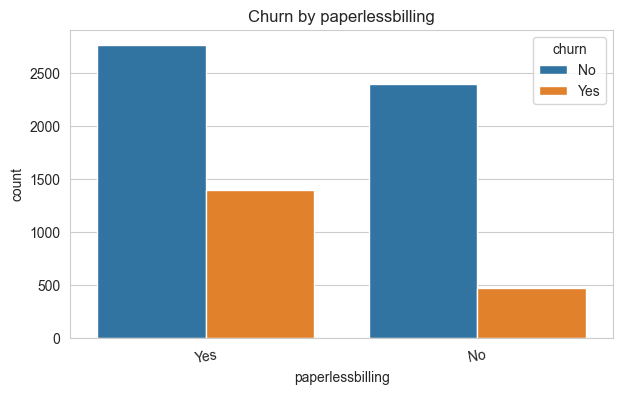

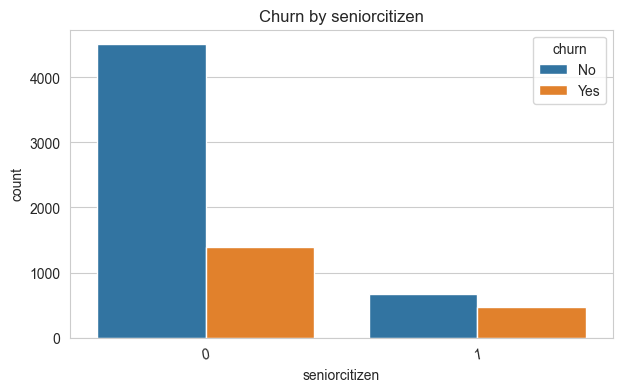

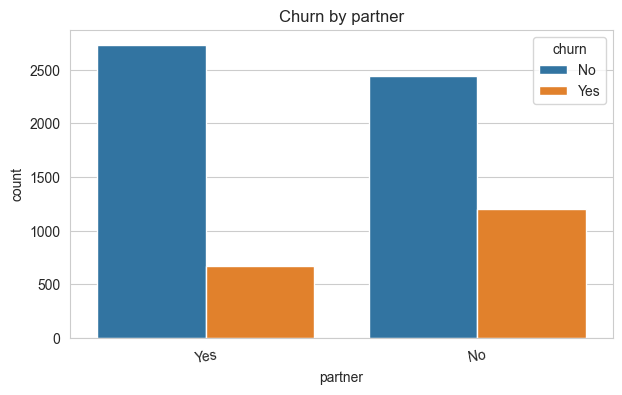

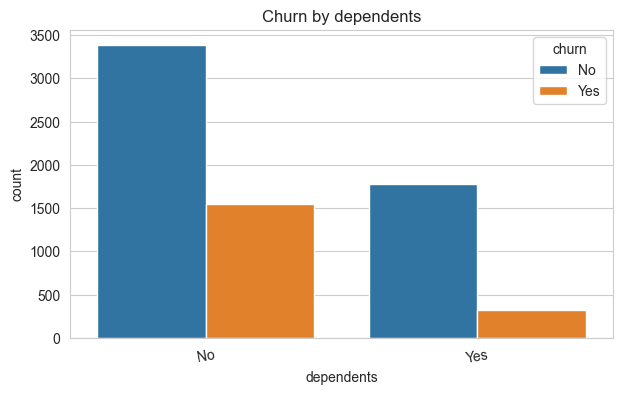

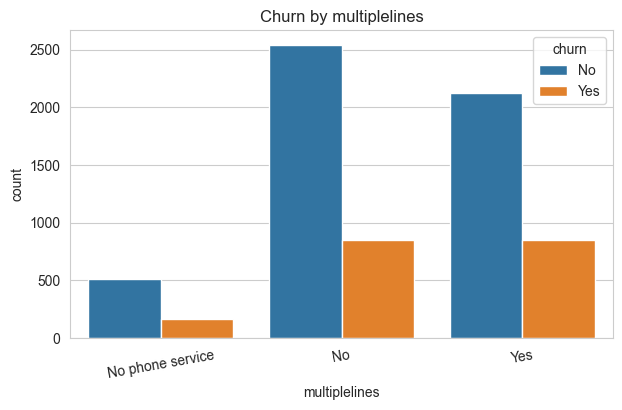

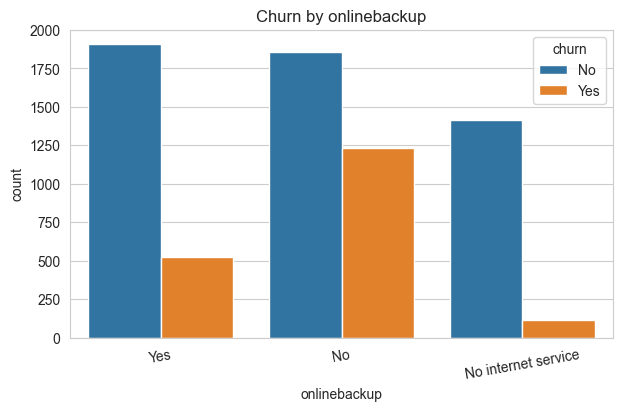

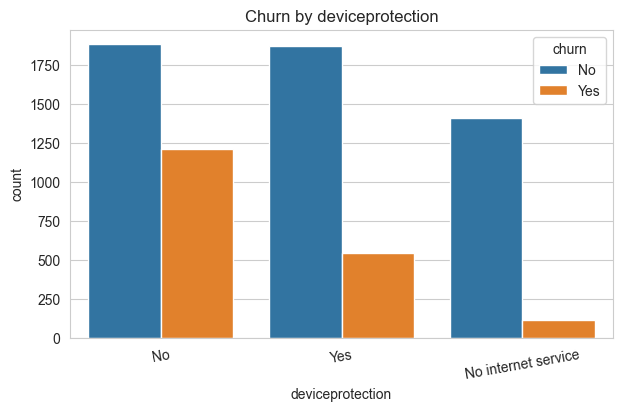

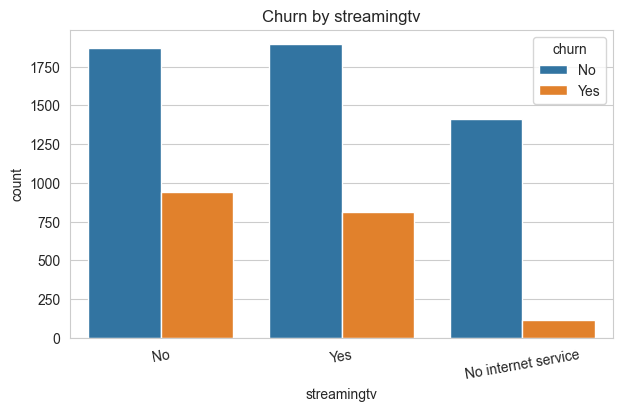

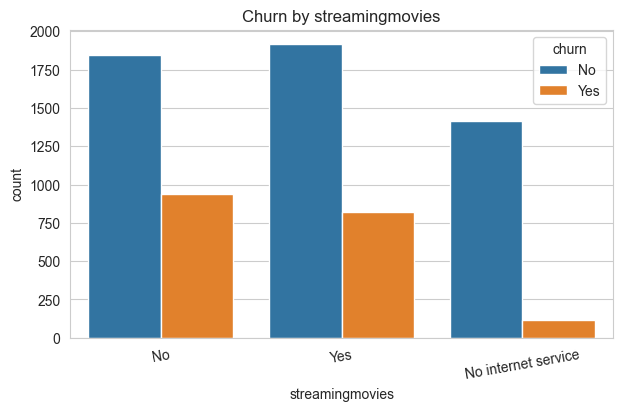

In [33]:
# Quick churn analysis for remaining categorical features

remaining_cols = [
    'paperlessbilling',
    'seniorcitizen',
    'partner',
    'dependents',
    'multiplelines',
    'onlinebackup',
    'deviceprotection',
    'streamingtv',
    'streamingmovies'
]

for col in remaining_cols:
    
    plt.figure(figsize=(7,4))
    
    sns.countplot(data=eda_df,
                  x=col,
                  hue='churn')
    
    plt.title(f'Churn by {col}')
    
    plt.xticks(rotation=10)
    
    plt.show()

### Additional Categorical Feature Insights

Customers using paperless billing show noticeably higher churn compared to customers using traditional billing methods. This may suggest that customers using digital billing are more flexible, more price-sensitive, or more likely to switch providers.

Senior citizens appear to have a relatively higher churn rate compared to non-senior customers. This could indicate differences in pricing sensitivity, service expectations, or customer support needs among older customers.

Customers with partners or dependents generally show lower churn levels. This suggests that family-related customers may prefer service stability and long-term retention compared to customers without family commitments.

Customers without online backup or device protection services show much higher churn than customers subscribed to these additional services. This indicates that customers using more value-added services are likely more engaged with the company and less willing to switch providers.

Streaming TV and streaming movie services show smaller differences in churn behavior compared to other service-related features. While customers using these services still exhibit churn, the relationship appears less significant than features such as contract type, tech support, or online security.

Overall, the analysis suggests that customer retention improves when customers are more integrated into the company’s service ecosystem through additional services, family-related commitments, and long-term usage behavior.

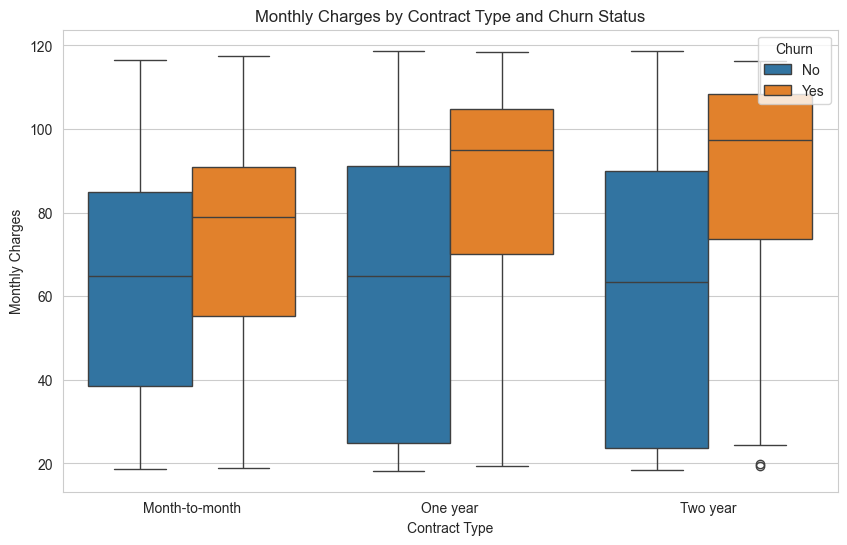

In [34]:
# Analyze monthly charges across contract types and churn
plt.figure(figsize=(10, 6))
sns.boxplot(x='contract', y='monthlycharges', hue='churn', data=eda_df)
plt.title('Monthly Charges by Contract Type and Churn Status')
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charges')
plt.legend(title='Churn', loc='upper right')
plt.show()

### Monthly Charges, Contract Type, and Churn Insight

Customers who churn generally show higher monthly charges across all contract types, reinforcing earlier findings that higher pricing is associated with increased churn risk.

However, long-term contract customers still show lower overall churn compared to month-to-month customers, even when monthly charges are relatively high. This suggests that contract commitment may help reduce churn by increasing customer stability and lowering switching behavior.

The chart also shows that some customers on one-year and two-year contracts who eventually churn tend to belong to higher-paying customer groups. This indicates that the company may still be losing valuable premium customers despite long-term agreements.

Overall, the findings suggest that while higher pricing increases churn risk, long-term contracts may partially offset that risk by improving customer retention and long-term commitment.

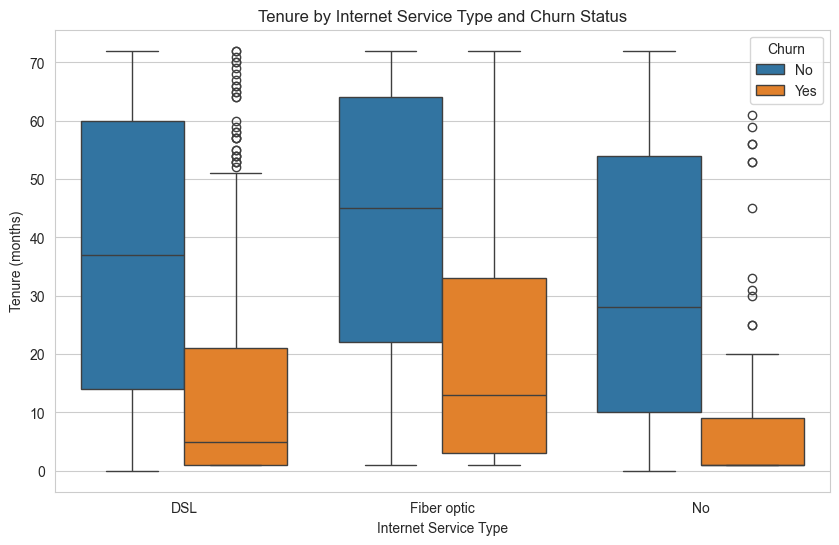

In [35]:
# Analyze tenure across internet service and churn

plt.figure(figsize=(10, 6))
sns.boxplot(x='internetservice', y='tenure', hue='churn', data=eda_df)
plt.title('Tenure by Internet Service Type and Churn Status')
plt.xlabel('Internet Service Type')
plt.ylabel('Tenure (months)')
plt.legend(title='Churn', loc='upper right')
plt.show()

### Tenure, Internet Service, and Churn Insight

Customers with fiber optic internet show higher churn overall, but many of the churned customers also have relatively longer tenure compared to DSL churners.

This suggests that fiber optic customers do not always leave immediately. Instead, some remain with the company for a longer period before eventually churning, possibly due to ongoing dissatisfaction with service quality, support experience, pricing, or unmet expectations over time.

DSL customers who churn tend to have much shorter tenure, indicating that dissatisfied DSL customers may leave earlier in their customer journey.

Customers without internet service show relatively low churn levels overall, suggesting that simpler service users may experience fewer service-related issues and lower dissatisfaction risk.

Overall, the analysis shows that churn behavior differs across internet service types, and that premium internet customers may remain subscribed for some time before eventually deciding to leave the service.

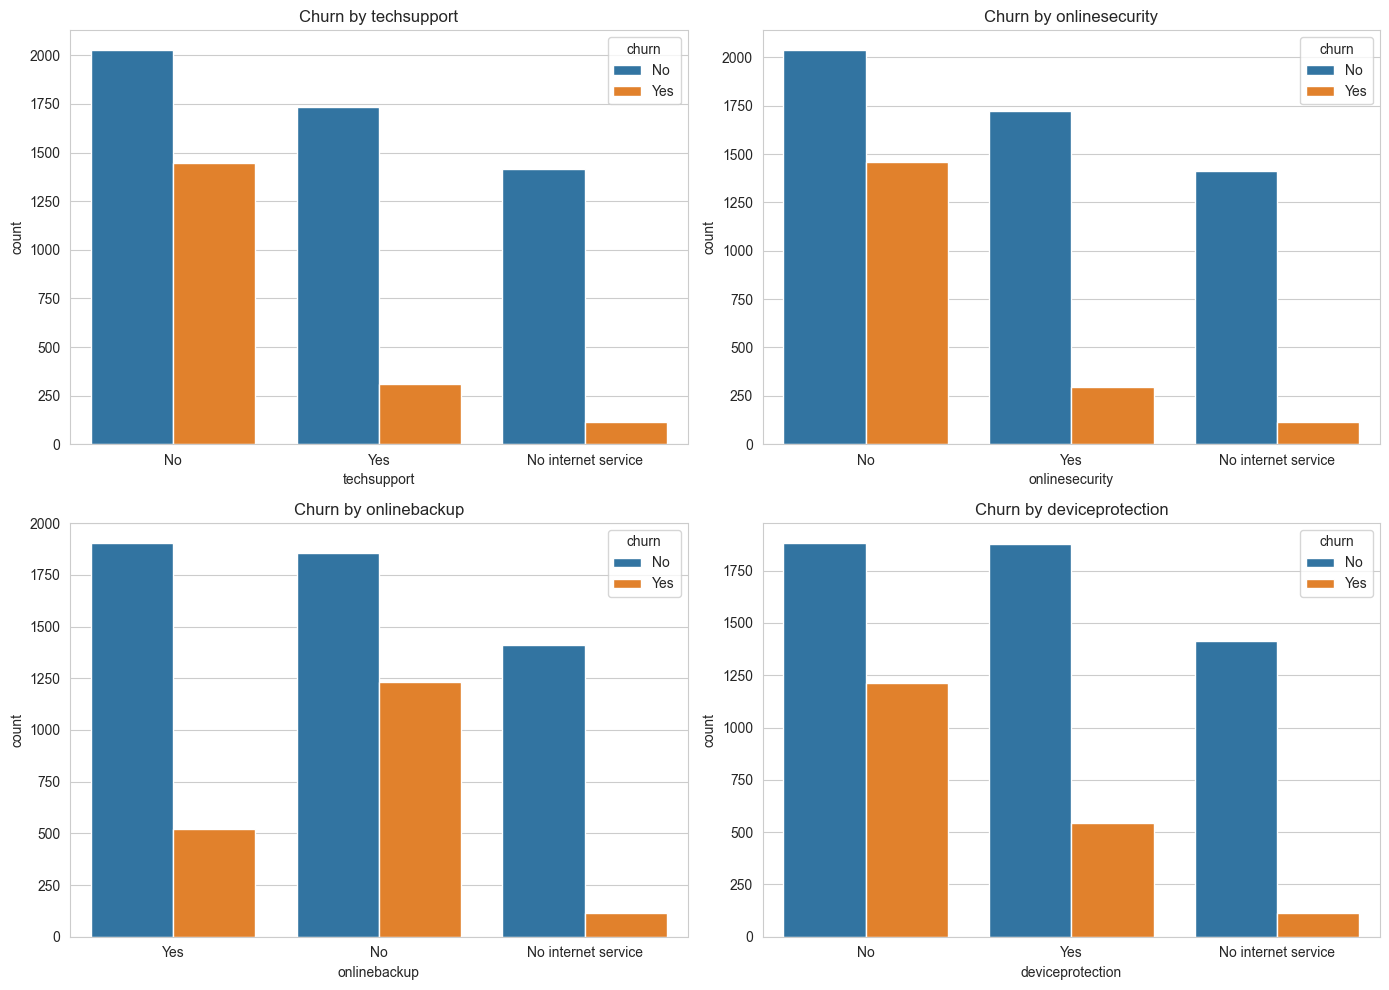

In [36]:
# Compare churn across support-related services

support_cols = [
    'techsupport',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection'
]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, col in zip(axes.flatten(), support_cols):
    
    sns.countplot(data=eda_df,
                  x=col,
                  hue='churn',
                  ax=ax)
    
    ax.set_title(f'Churn by {col}')

plt.tight_layout()

plt.show()

### Support and Protection Services vs Churn Insight

Customers without support and protection services consistently show higher churn across multiple service categories, including tech support, online security, online backup, and device protection.

This suggests that customers who use additional support-related services are generally more engaged with the company and may feel more secure and supported while using the services provided.

Customers with no internet service show relatively low churn levels, likely because they use simpler services with fewer technical issues or support needs.

The analysis also shows that many customers without support services are still retained customers, meaning they could become future churn risks if their experience is not properly managed.

Overall, the findings suggest that improving customer engagement, technical support, and adoption of value-added protection services may help strengthen customer retention and reduce churn risk.

In [39]:
from phik import phik_matrix
import phik

# Calculate the Phik correlation matrix
phik_corr = eda_df.drop('customerid', axis=1). phik_matrix()

# getting correlation with churn
churn_corr = phik_corr['churn'].sort_values(ascending=False)
print(churn_corr)

interval columns not set, guessing: ['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges']
churn               1.000000
tenure              0.474001
paymentmethod       0.449125
monthlycharges      0.360038
paperlessbilling    0.295754
totalcharges        0.278498
dependents          0.253936
contract            0.251639
seniorcitizen       0.233432
partner             0.232930
onlinesecurity      0.211840
techsupport         0.209021
internetservice     0.196202
onlinebackup        0.177422
deviceprotection    0.170762
streamingmovies     0.139522
streamingtv         0.139246
multiplelines       0.021922
phoneservice        0.000000
gender              0.000000
Name: churn, dtype: float64


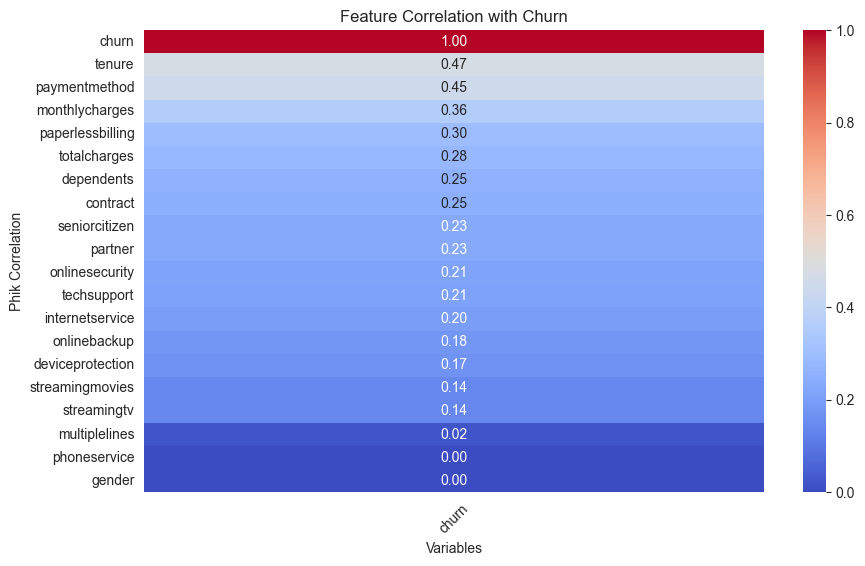

In [42]:
# visualize correlation with churn
plt.figure(figsize=(10, 6))
sns.heatmap(churn_corr.to_frame(), annot=True, cmap='coolwarm', fmt='.2f', yticklabels=churn_corr.index )
plt.title('Feature Correlation with Churn')
plt.xlabel('Variables')
plt.ylabel('Phik Correlation')
plt.xticks(rotation=45)
plt.show()

### Correlation Analysis Insight

The correlation analysis shows that `tenure` has the strongest relationship with churn among all features in the dataset. This supports earlier findings that customers with shorter tenure are more likely to leave the company.

Other important features associated with churn include payment method, monthly charges, paperless billing, contract type, and support-related services such as tech support and online security.

Features like gender and phone service show almost no relationship with churn, suggesting that they may contribute little to churn prediction compared to behavioral and service-related variables.

Overall, the results indicate that customer churn is influenced by multiple factors rather than a single variable. Customer commitment, pricing, billing behavior, and service experience all appear to play important roles in customer retention.